# proteon-pyg quickstart

Interactive walkthrough of [proteon-pyg](https://github.com/theGreatHerrLebert/proteon-pyg).
Covers:

1. Build a residue-level `Data` from a single PDB
2. Inspect the tensor schema and decode DSSP
3. Switch to atom-level (dual-resolution Data)
4. Use the `ProteonFeatures` transform in a PyG `Dataset` pipeline
5. Build many `Data` objects in one parallel call
6. Quick plots: Ramachandran, SASA distribution

Requires: `proteon>=0.2.0`, `torch`, `torch_geometric`. Run cells top to
bottom — each is editable, that's the point.


In [1]:
from importlib.metadata import version
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import proteon
import proteon_pyg

print(f"proteon       {version('proteon')}")
print(f"proteon_pyg   {proteon_pyg.__version__}")
print(f"torch         {torch.__version__}")

PDB_DIR = Path('/scratch/TMAlign/proteon/test-pdbs')
PDB_1CRN = PDB_DIR / '1crn.pdb'
PDB_1AKE = PDB_DIR / '1ake.pdb'


proteon       0.1.4
proteon_pyg   0.0.3
torch         2.11.0+cu130


## 1. Residue-level Data from one PDB

The simplest entry point: pass a path, get a `Data` with proteon
features attached as tensors. Every flag is optional — toggle them and
re-run to see what each one adds.


In [2]:
data = proteon_pyg.proteon_pyg_data(
    PDB_1CRN,
    sasa=True,
    dssp=True,
    energy=True,
    hbond_count=True,
    dihedrals=True,
)
data


/scratch/TMAlign/proteon/.venv/lib/python3.12/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12050). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


Data(pos=[46, 3], chain_id=[46], residue_number=[46], insertion_code=[46], residue_name=[46], is_amino_acid=[46], residue_sasa=[46], rsa=[46], dssp=[46], hbond_count=[46], phi=[46], psi=[46], omega=[46], proteon_energy_bond_stretch=356.4528876965733, proteon_energy_angle_bend=288.8527834548742, proteon_energy_torsion=229.9402165964358, proteon_energy_improper_torsion=40.254452844950485, proteon_energy_vdw=-748.2978035968084, proteon_energy_electrostatic=1303.0346859915976, proteon_energy_solvation=-1377.0452353847802, proteon_energy_total=93.19198760284279, proteon_energy_n_unassigned_atoms=0.0, proteon_energy_n_topo_atoms=327.0, proteon_energy_n_bonds=337.0, proteon_energy_n_angles=466.0, proteon_energy_n_torsions=211.0, proteon_energy_n_impropers=137.0, proteon_energy_n_excluded_pairs=803.0, proteon_energy_n_14_pairs=534.0, proteon_ff='charmm19_eef1')

## 2. Tensor schema

Per-residue tensors land at residue resolution. DSSP is integer-encoded
(0..7 per `DSSP_CLASSES`); use `decode_dssp` to round-trip back to the
canonical 8-character string.


In [3]:
from proteon_pyg import DSSP_CLASSES, decode_dssp

print('shapes:')
print(f'  pos          {tuple(data.pos.shape)}')
print(f'  residue_sasa {tuple(data.residue_sasa.shape)}')
print(f'  dssp (int)   {tuple(data.dssp.shape)} — values in -1..7')
print(f'  phi/psi      {tuple(data.phi.shape)} — NaN at chain termini')
print()
print(f'DSSP classes: {DSSP_CLASSES}')
print(f'DSSP decoded: {decode_dssp(data.dssp)}')
print()
print(f'energy total: {float(data.proteon_energy_total.item()):.2f} kJ/mol')
print(f'force field:  {data.proteon_ff}')


shapes:
  pos          (46, 3)
  residue_sasa (46,)
  dssp (int)   (46,) — values in -1..7
  phi/psi      (46,) — NaN at chain termini

DSSP classes: ('H', 'B', 'E', 'G', 'I', 'T', 'S', 'C')
DSSP decoded: CEECSTHHHHHHHHHHHTTTTTHHHHHHHHTCEECSSSCCTTTTCC

energy total: 93.19 kJ/mol
force field:  charmm19_eef1


NaN positions (chain termini for phi/psi, non-standard residues for RSA)
need NaN-aware filters before reductions:


In [4]:
phi_finite = data.phi[~torch.isnan(data.phi)]
print(f'mean phi (NaN-filtered): {phi_finite.mean().item():.1f} deg')
print(f'phi NaN count:           {torch.isnan(data.phi).sum().item()} (one per chain N-terminus)')


mean phi (NaN-filtered): -74.8 deg
phi NaN count:           1 (one per chain N-terminus)


## 3. Atom-level — dual-resolution Data

Pass `granularity="atom"` and you get a Data with both per-atom tensors
**and** the same per-residue tensors at their natural shape. The two
resolutions are linked via `data.residue_index` so you can broadcast
residue features back to atoms when you need them.


In [5]:
data_atom = proteon_pyg.proteon_pyg_data(
    PDB_1CRN, granularity='atom', hbond_count=True
)

print('per-atom (length N_atoms):')
print(f'  pos           {tuple(data_atom.pos.shape)}')
print(f'  atom_sasa     {tuple(data_atom.atom_sasa.shape)}')
print(f'  charge        {tuple(data_atom.charge.shape)}')
print(f'  is_backbone   {tuple(data_atom.is_backbone.shape)}')
print(f'  residue_index {tuple(data_atom.residue_index.shape)}')
print()
print('per-residue (length N_residues):')
print(f'  residue_sasa  {tuple(data_atom.residue_sasa.shape)}')
print(f'  dssp          {tuple(data_atom.dssp.shape)}')
print()
# Broadcast on demand:
per_atom_dssp = data_atom.dssp[data_atom.residue_index]
print(f'broadcast dssp.shape  {tuple(per_atom_dssp.shape)}  (now per-atom)')


per-atom (length N_atoms):
  pos           (327, 3)
  atom_sasa     (327,)
  charge        (327,)
  is_backbone   (327,)
  residue_index (327,)

per-residue (length N_residues):
  residue_sasa  (46,)
  dssp          (46,)

broadcast dssp.shape  (327,)  (now per-atom)


## 4. ProteonFeatures transform — slot into a PyG Dataset

`ProteonFeatures` is a PyG `BaseTransform`. Each input `Data` must carry
a `pdb_path` attribute pointing to the source PDB. Mutates the Data in
place.


In [6]:
from torch_geometric.data import Data

raw = Data()
raw.pdb_path = str(PDB_1CRN)

tf = proteon_pyg.ProteonFeatures(hbond_count=True, dihedrals=True)
print(tf)

attached = tf(raw)
assert attached is raw, 'transform mutates the same Data instance'
print(f'\nattributes after transform: {sorted(attached.to_dict().keys())[:8]}...')


ProteonFeatures(granularity=residue, sasa=True, dssp=True, energy=True, hbond_count=True, dihedrals=True, ff='charmm19_eef1')

attributes after transform: ['chain_id', 'dssp', 'hbond_count', 'insertion_code', 'is_amino_acid', 'omega', 'pdb_path', 'phi']...


## 5. Batch — many PDBs in one parallel call

`proteon_pyg_data_batch` takes a list of paths and returns a list of
`Data` objects. Today the batch helper is more useful as a unified API
than a hard speed win on tiny PDBs (see `demos/README.md` for the actual
numbers). It's a parity-test-equivalent of a single-call loop, with
parallel `batch_load` underneath.


In [7]:
datas = proteon_pyg.proteon_pyg_data_batch(
    [PDB_1CRN, PDB_1AKE, PDB_1CRN],
    granularity='residue',
    hbond_count=True,
)

for i, d in enumerate(datas):
    n_aa = int(d.is_amino_acid.sum().item())
    print(f'data[{i}]: {d.pos.shape[0]} residues ({n_aa} AA), '
          f'energy={float(d.proteon_energy_total.item()):.1f} kJ/mol')


data[0]: 46 residues (46 AA), energy=93.2 kJ/mol
data[1]: 808 residues (428 AA), energy=-1985.6 kJ/mol
data[2]: 46 residues (46 AA), energy=93.2 kJ/mol


PyG's standard batching collates them into a single `Batch` for GNN
training:


In [8]:
from torch_geometric.data import Batch

batch = Batch.from_data_list(datas)
print(batch)
print(f'\ntotal residues across batch: {batch.num_nodes}')


DataBatch(pos=[900, 3], chain_id=[3], residue_number=[900], insertion_code=[3], residue_name=[3], is_amino_acid=[900], residue_sasa=[900], rsa=[900], dssp=[900], hbond_count=[900], proteon_energy_bond_stretch=[3], proteon_energy_angle_bend=[3], proteon_energy_torsion=[3], proteon_energy_improper_torsion=[3], proteon_energy_vdw=[3], proteon_energy_electrostatic=[3], proteon_energy_solvation=[3], proteon_energy_total=[3], proteon_energy_n_unassigned_atoms=[3], proteon_energy_n_topo_atoms=[3], proteon_energy_n_bonds=[3], proteon_energy_n_angles=[3], proteon_energy_n_torsions=[3], proteon_energy_n_impropers=[3], proteon_energy_n_excluded_pairs=[3], proteon_energy_n_14_pairs=[3], proteon_ff=[3], batch=[900], ptr=[4])

total residues across batch: 900


## 6. Quick plots

Ramachandran scatter from `data.phi` × `data.psi`:


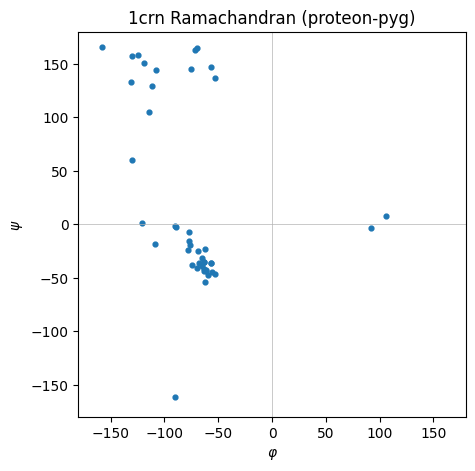

In [9]:
phi = data.phi[~torch.isnan(data.phi) & ~torch.isnan(data.psi)]
psi = data.psi[~torch.isnan(data.phi) & ~torch.isnan(data.psi)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(phi.numpy(), psi.numpy(), s=12)
ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
ax.set_xlabel(r'$\varphi$'); ax.set_ylabel(r'$\psi$')
ax.set_title('1crn Ramachandran (proteon-pyg)')
ax.axhline(0, color='0.7', linewidth=0.5)
ax.axvline(0, color='0.7', linewidth=0.5)
plt.show()


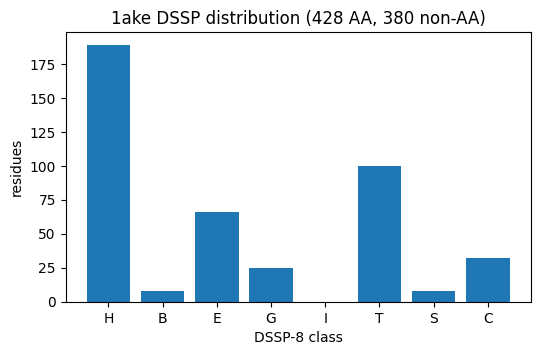

In [10]:
# DSSP class histogram on 1ake (mixed AA + HETATM)
data_1ake = proteon_pyg.proteon_pyg_data(PDB_1AKE)
codes = data_1ake.dssp.numpy()

aa_codes = codes[codes >= 0]
counts = np.bincount(aa_codes, minlength=8)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(DSSP_CLASSES, counts)
ax.set_xlabel('DSSP-8 class'); ax.set_ylabel('residues')
ax.set_title(f'1ake DSSP distribution ({len(aa_codes)} AA, '
             f'{len(codes)-len(aa_codes)} non-AA)')
plt.show()


## What to try next

- Open `demos/sanity_demo.py` — same plots, produced as PNG artifacts
  rather than inline.
- Open `demos/infra_demo.py` — timing the batch helper against a Python
  loop. Surfaces a real upstream perf gap for small-PDB batches that's
  invisible from parity tests alone.
- Read `evident.yaml` for the parity claim contract — every tensor on
  every Data is exact-equal (post `.numpy()` round-trip) to direct
  proteon API output. That's what underwrites everything above.
